In [2]:
import numpy as np
import os
import pandas as pd

import libcontext
from scripts.pipeline import Config

# Parameters
base_path = "../scripts/gradients"
opt_names = [ "Vanilla_SGD", "FullAdaGrad", "Torch_Adagrad", "AdaGramPS"]

# Define unique hyperparameters for each optimizer
# The 'rank' is now handled on a per-optimizer basis.
hyperparams = {}
config = Config("../scripts/config.yaml")


for opt_name, opt_config in config.optimizers.items():
    # Skip any optimizer that is not marked as 'enabled'
    if not opt_config.get('enabled', False):
        continue

    # Extract the first value from each hyperparameter list, if it exists
    lr = opt_config.get('learning_rates', [None])[0]
    bs = opt_config.get('batch_size', [None])[0]
    eps_raw = opt_config.get('eps', [None])[0]
    
    # Handle the 'nan' case for eps
    eps = 'nan' if str(eps_raw).lower() == 'nan' else eps_raw

    # Conditionally extract rank only if required
    rank = None
    if opt_config.get('requires_rank', False):
        rank = opt_config.get('ranks', [None])[0]
    
    # Assemble the dictionary for the current optimizer
    hyperparams[opt_name] = {
        'lr': lr,
        'bs': bs,
        'eps': eps,
        'rank': rank
    }

# General parameters
epochs = 20
num_points = 240

# --- Data Loading and Processing Cycle ---

# This list will store the records for the final DataFrame.
records = []

# Loop through each optimizer to load, process, and analyze its data.
for opt_name in opt_names:
    # Get the specific hyperparameters for the current optimizer
    params = hyperparams[opt_name]
    lr, eps, bs, rank = params['lr'], params['eps'], params['bs'], params['rank']
    
    print(f"Processing data for optimizer: {opt_name} with params: {params}")

    # Temporary storage for the gradient tensors of the current optimizer
    optimizer_tensors = []

    # Load gradients for each epoch
    # Assumes filenames are numbered from 1 to epochs
    for epoch in range(1, epochs + 1):
        # Construct the filename using the optimizer-specific hyperparameters
        filename = f"epoch-{epoch}_lr-{lr}_eps-{eps}_bs-{bs}_rank-{rank}.npz"
        file_path = os.path.join(base_path, opt_name, filename)
        
        if os.path.exists(file_path):
            try:
                data = np.load(file_path, allow_pickle=True)
                # Assumes the first array in the file is the gradient tensor
                tensor_np = data[data.files[0]]
                optimizer_tensors.append(tensor_np)
            except Exception as e:
                print(f"Could not load or process file {file_path}: {e}")
        else:
            print(f"File not found: {file_path}")

    # --- Analysis for the current optimizer ---
    
    # Proceed only if any tensors were loaded for this optimizer
    if not optimizer_tensors:
        print(f"No data found for optimizer: {opt_name}. Skipping analysis.")
        continue

    # Stack the list of tensors into a single NumPy array
    # Shape: [epochs, batches, dim1, dim2]
    stacked_tensors = np.stack(optimizer_tensors)
    
    # Iterate through the loaded epochs for analysis
    for epoch_idx, r_ep_arr in enumerate(stacked_tensors):
        # Calculate variance and mean for each batch tensor
        variances = np.var(r_ep_arr, axis=(1, 2))
        means = np.mean(r_ep_arr, axis=(1, 2))
        max_vals = np.max(np.abs(r_ep_arr), axis=(1, 2))
        min_vals = np.min(np.abs(r_ep_arr), axis=(1, 2)) 
        
        # Check for numerical issues
        if np.isnan(r_ep_arr).any():
            print(f"NaN found for optimizer {opt_name}, rank {rank}, epoch {epoch_idx + 1}")
        if np.isinf(r_ep_arr).any():
            print(f"Infinity found for optimizer {opt_name}, rank {rank}, epoch {epoch_idx + 1}")

        # Append records with the optimizer name
        for batch_idx, var in enumerate(variances):
            records.append({
                'optimizer': opt_name,
                'rank': rank,
                'epoch': epoch_idx + 1,  # Use 1-based epoch for consistency with filenames
                'step': (num_points / bs) * epoch_idx + batch_idx,
                'batch_idx': batch_idx,
                'variance': var,
                'mean': means[batch_idx],
                'min': min_vals[batch_idx],
                'max': max_vals[batch_idx]
            })

# --- Final DataFrame Creation ---
df = pd.DataFrame(records)

# Display the first few rows and info of the DataFrame to verify
print("\nDataFrame Head:")
print(df.head())
print("\nDataFrame Info:")
df.info()



Processing data for optimizer: Vanilla_SGD with params: {'lr': 0.001, 'bs': 1, 'eps': 'nan', 'rank': None}
Processing data for optimizer: FullAdaGrad with params: {'lr': 0.001, 'bs': 1, 'eps': 0.01, 'rank': None}
Processing data for optimizer: Torch_Adagrad with params: {'lr': 0.001, 'bs': 1, 'eps': 0.01, 'rank': None}
Processing data for optimizer: AdaGramPS with params: {'lr': 0.001, 'bs': 1, 'eps': 0.01, 'rank': 1}

DataFrame Head:
     optimizer  rank  epoch  step  batch_idx  variance          mean  min  \
0  Vanilla_SGD   NaN      1   0.0          0  0.274892 -1.064369e-08  0.0   
1  Vanilla_SGD   NaN      1   1.0          1  0.061806  1.064369e-09  0.0   
2  Vanilla_SGD   NaN      1   2.0          2  0.111625 -8.514950e-09  0.0   
3  Vanilla_SGD   NaN      1   3.0          3  0.057690  1.064369e-08  0.0   
4  Vanilla_SGD   NaN      1   4.0          4  0.354544  0.000000e+00  0.0   

        max  
0  0.670383  
1  0.301501  
2  0.409057  
3  0.292206  
4  0.762537  

DataFrame Inf

In [3]:
len(df)

84160

KeyboardInterrupt: 

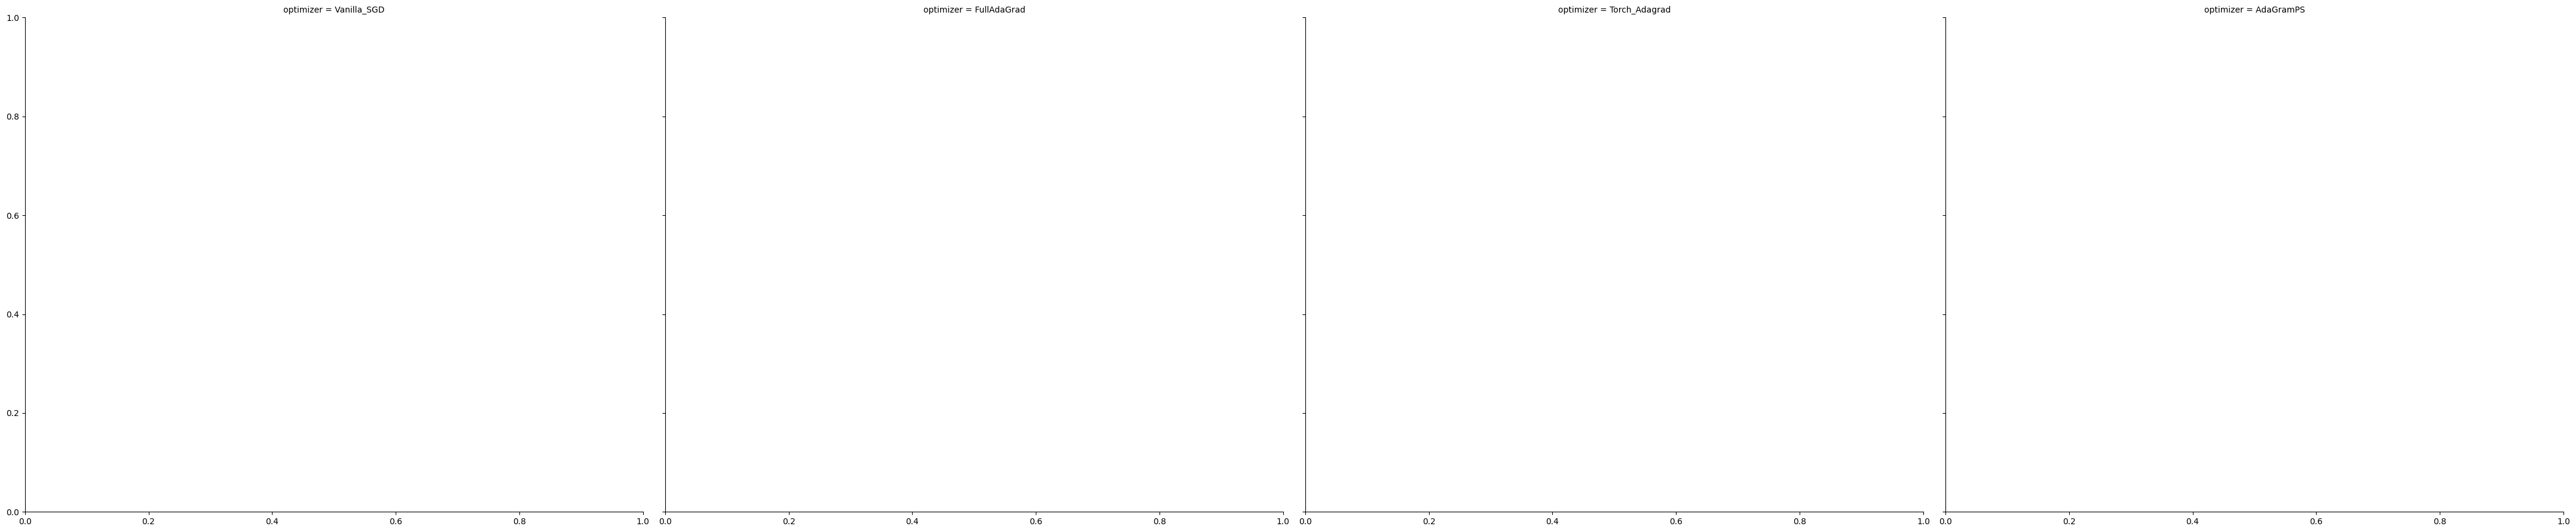

In [4]:
import seaborn as sns 
import matplotlib.pyplot as plt

g = sns.FacetGrid(
    data=df,
    col='optimizer',
    height=9,
    aspect=1.2,
    sharex=False  # Allow axes to be independent
)

# 2. Map the plotting function to the grid.
g.map_dataframe(sns.lineplot, x='step', y='mean', marker='o', color='cornflowerblue')

# 3. Manually iterate and set x-axis limits for each subplot.
# This is the new section that solves the problem.
for ax, opt_name in zip(g.axes.flat, g.col_names):
    # Filter the DataFrame to get data for only the current optimizer
    opt_df = df[df['optimizer'] == opt_name]
    
    if not opt_df.empty:
        # Calculate the min and max step for this specific optimizer
        min_step = opt_df['step'].min()
        max_step = opt_df['step'].max()
        
        # Set the x-axis limit with a small amount of padding
        padding = (max_step - min_step) * 0.05 # 5% padding
        ax.set_xlim(min_step - padding, max_step + padding)
for ax in g.axes.flat:
    ax.set_xlabel("Training Step", fontsize=24)
    ax.set_ylabel("Mean Gradient", fontsize=24)
    ax.tick_params(axis='both', labelsize=24) # Adjust tick label size as well

# 4. Set final titles and labels for clarity.
g.set_axis_labels('Training Step', 'Mean Gradient')
g.set_titles(col_template='Optimizer: {col_name}')
g.fig.subplots_adjust(top=0.85)
g.set_titles(col_template='{col_name}', size=20) # Use just {col_name} for a cleaner look

# Adjust layout and add a main title
g.fig.subplots_adjust(top=0.82) # Adjust to prevent title overlap
g.fig.suptitle('Mean Gradients per Optimizer', fontsize=24)
# g.fig.suptitle('Mean Gradients with Custom X-Axes per Optimizer', fontsize=16)
g.fig.savefig(
    "gradients_mean.pdf",  # Specify filename and format (png, pdf, svg, etc.)
    dpi=300,                # Set the resolution (dots per inch) for higher quality
    bbox_inches='tight'     # Adjusts the plot to prevent labels from being cut off
)

# You can still show the plot after saving it
plt.show()

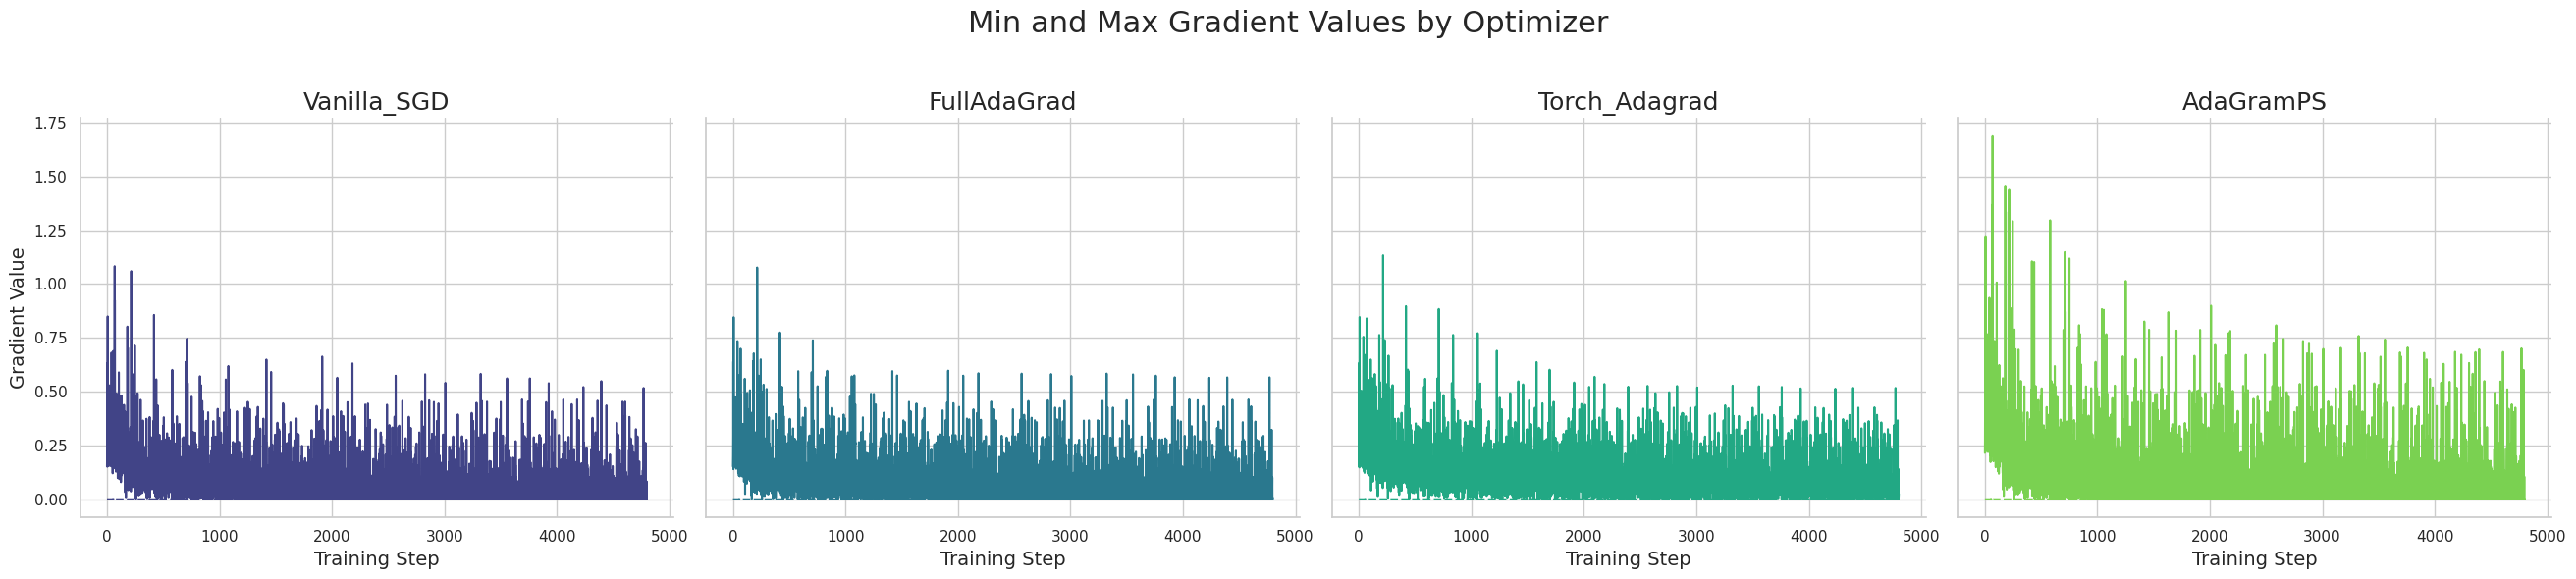

In [24]:
def sns_plot_min_max_lines(data, **kwargs):
    """
    Draws two separate lines for the 'min' and 'max' values 
    on the current matplotlib Axes object.
    """
    # Get the current Axes object and color
    ax = plt.gca()
    color = kwargs.pop('color')
    
    # KEY FIX: Remove the label passed automatically by FacetGrid 
    # to prevent a conflict with our manually set labels ('Min', 'Max').
    kwargs.pop('label', None)

    # Plot the 'max' value with a solid line
    ax.plot(data['step'], data['max'], color=color, linestyle='-', label='Max', **kwargs)
    # Plot the 'min' value with a dashed line
    ax.plot(data['step'], data['min'], color=color, linestyle='--', label='Min', **kwargs)
    # Add a legend to this specific subplot to identify the lines
    ax.legend()


# --- Plotting Logic ---
sns.set(style="whitegrid")

# Create a FacetGrid, passing color information via the 'hue' parameter
g = sns.FacetGrid(df, col='optimizer', height=6, aspect=1.1, sharex=False,
                  hue='optimizer', palette='viridis')

# Map the CORRECTED plotting function onto the grid
g.map_dataframe(sns_plot_min_max_lines)

# Set final labels and titles
g.set_axis_labels("Training Step", "Gradient Value", fontsize=14)
g.set_titles(col_template="{col_name}", size=18)
g.fig.suptitle("Min and Max Gradient Values by Optimizer", fontsize=22)

# Adjust the layout
g.fig.tight_layout(rect=[0, 0, 1, 0.95])

plt.show()


In [5]:
import numpy as np
import os

# Parameters
def matrix_G_df(rank, epochs):
    base_path = "state_G_PSI"
    lr = 0.1

    # Prepare storage for each rank
    G_matrices = {epoch: [] for epoch in range(epochs)}
    G_records = []

    # Load gradients for each epoch and rank
    for epoch in range(epochs):
        filename = f"{task_name}_state_G_lr_{lr}_rank_{rank}_epoch_{epoch}.npz"
        file_path = os.path.join(base_path, filename)
        if os.path.exists(file_path):
            data = np.load(file_path)
            # Assumes the first array in the file is the gradient tensor
            tensor_np = data[data.files[0]]
            max_abs_val = np.max(abs(tensor_np))
            mean=np.mean(tensor_np)
            G_records.append({'rank': rank, 'epoch': epoch, 'max_value': max_abs_val, "mean": mean})
            G_matrices[epoch].append(tensor_np)
        else:
            print(f"File not found: {file_path}")

    df_matrix_G = pd.DataFrame(G_records)
    return df_matrix_G



In [6]:
ranks = [1, 2, 3, 4, 5]
dfs = []
epochs = 100
for rank in ranks:
    cur_df = matrix_G_df(rank, epochs)
    dfs.append(cur_df)

df = pd.concat(dfs)
df.head()

,rank,epoch,max_value,mean
0,1,0,30.310276,0.500001
1,1,1,46.796982,0.499996
2,1,2,60.207859,0.499996
3,1,3,71.802620,0.500000
4,1,4,82.327988,0.500000


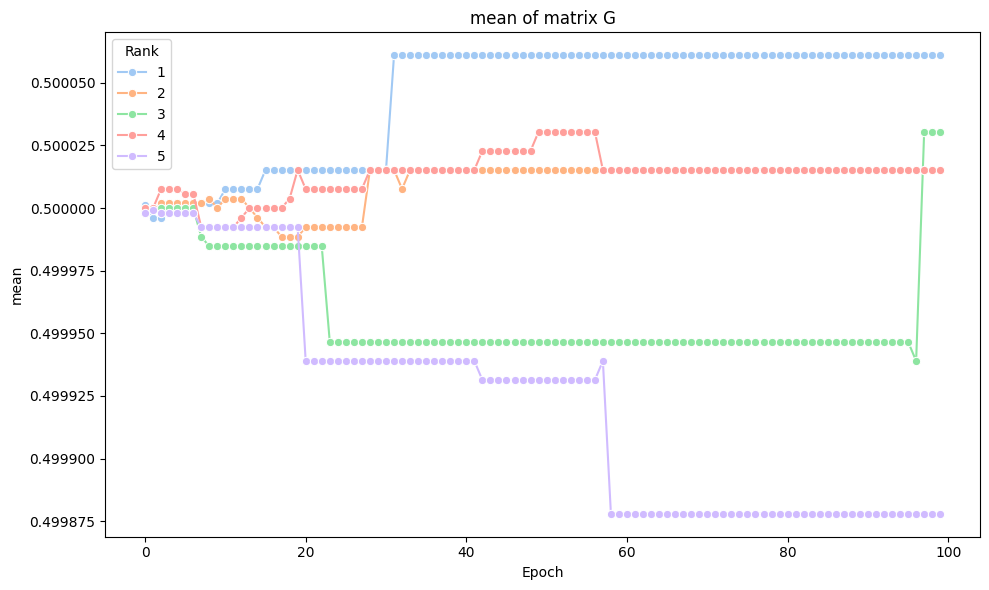

In [7]:
import seaborn as sns
import matplotlib.pyplot as plt

# Assuming your DataFrame is named 'df' and has columns: 'rank', 'epoch', 'variance'
plt.figure(figsize=(10, 6))
sns.lineplot(data=df, x='epoch', y='mean', hue='rank', marker='o', palette='pastel',)

plt.xlabel('Epoch')
plt.ylabel('mean')
plt.title('mean of matrix G')
plt.legend(title='Rank')
plt.tight_layout()
plt.show()
